# 06 — Dataset dan DataLoader Citra Awan

Notebook ini membangun objek `Dataset` dan `DataLoader` PyTorch untuk klasifikasi
jenis awan menggunakan hasil dari tahap split, preprocessing, dan augmentasi.

Notebook ini tidak melakukan pembagian dataset, pembersihan citra, atau pembuatan
augmentasi baru. Seluruh informasi dataset dibaca dari metadata yang sudah disimpan
di `dataset/processed/`.

Tujuan notebook:

1. Membaca indeks dataset hasil notebook 05.
2. Membaca pemetaan kelas yang sudah ditetapkan.
3. Memuat pipeline transform training dan evaluasi.
4. Membentuk custom PyTorch Dataset.
5. Membentuk DataLoader train, validation, dan test.
6. Memastikan dimensi tensor dan label sesuai.
7. Memeriksa distribusi kelas pada DataLoader.
8. Memvisualisasikan satu batch training.
9. Menyimpan konfigurasi DataLoader.
10. Menyiapkan input untuk tahap training model.

Data test hanya dibentuk sebagai DataLoader. Data test tidak dianalisis atau digunakan
untuk pemilihan model dan hyperparameter.

## Mengimpor Library

Library yang digunakan terbatas pada pengelolaan metadata, pembacaan citra,
transformasi, visualisasi, dan pembentukan DataLoader PyTorch.

In [1]:
from pathlib import Path
import json
import math
import random
import sys

try:
    import albumentations as A
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import torch

    from IPython.display import display
    from torch.utils.data import (
        DataLoader,
        Dataset,
        RandomSampler,
        get_worker_info,
    )

    # Import ini juga memastikan ToTensorV2 terdaftar
    # ketika pipeline Albumentations dimuat dari JSON.
    from albumentations.pytorch import ToTensorV2

except ImportError as exc:
    raise ImportError(
        "Dependency DataLoader belum lengkap.\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

cv2.setNumThreads(0)


print(f"Python          : {sys.version.split()[0]}")
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"PyTorch         : {torch.__version__}")
print(f"OpenCV          : {cv2.__version__}")
print(f"Albumentations  : {A.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")

Python          : 3.11.9
NumPy           : 2.4.6
Pandas          : 3.0.5
PyTorch         : 2.11.0+cu128
OpenCV          : 5.0.0
Albumentations  : 2.0.8
CUDA tersedia   : True


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan dari folder
utama project maupun folder `notebooks`.

Notebook tidak menggunakan path absolut Docker `/app`.

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

SOURCE_TRAIN_DIR = SOURCE_DIR / "train"
SOURCE_VAL_DIR = SOURCE_DIR / "val"
SOURCE_TEST_DIR = SOURCE_DIR / "test"


DATASET_INDEX_PATH = (
    PROCESSED_DIR
    / "preprocessing_dataset_index.csv"
)

CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "class_mapping.json"
)

PREPROCESSING_CONFIG_PATH = (
    PROCESSED_DIR
    / "preprocessing_config.json"
)

TRAIN_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "train_transform.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)

DATALOADER_SUMMARY_PATH = (
    PROCESSED_DIR
    / "dataloader_summary.csv"
)

DATALOADER_CONFIG_PATH = (
    PROCESSED_DIR
    / "dataloader_config.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "SOURCE_DIR",
        "PROCESSED_DIR",
        "DATASET_INDEX_PATH",
        "CLASS_MAPPING_PATH",
        "PREPROCESSING_CONFIG_PATH",
        "TRAIN_TRANSFORM_PATH",
        "EVAL_TRANSFORM_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        SOURCE_DIR,
        PROCESSED_DIR,
        DATASET_INDEX_PATH,
        CLASS_MAPPING_PATH,
        PREPROCESSING_CONFIG_PATH,
        TRAIN_TRANSFORM_PATH,
        EVAL_TRANSFORM_PATH,
    ],
})

path_table["Ada"] = path_table["Path"].map(Path.exists)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,D:\n8n-logsiswaparalayang\cloud-classification,True
1,SOURCE_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source,True
2,PROCESSED_DIR,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
3,DATASET_INDEX_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\preprocessing_dataset_index.csv,True
4,CLASS_MAPPING_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\class_mapping.json,True
5,PREPROCESSING_CONFIG_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\preprocessing_config.json,True
6,TRAIN_TRANSFORM_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\train_transform.json,True
7,EVAL_TRANSFORM_PATH,D:\n8n-logsiswaparalayang\cloud-classification\dataset\processed\eval_transform.json,True


## Konfigurasi DataLoader

`NUM_WORKERS` menggunakan nilai awal `0` karena notebook dijalankan langsung melalui
VS Code pada Windows. Nilai tersebut menghindari masalah multiprocessing pada kernel
Jupyter.

Setelah pipeline stabil, nilai `NUM_WORKERS` dapat diuji menjadi `2` atau `4`.
Peningkatan nilai harus mempertimbangkan jumlah inti CPU, RAM, dan kecepatan media
penyimpanan.

`drop_last=False` digunakan agar seluruh citra tetap dipakai, termasuk batch terakhir
yang jumlahnya lebih kecil daripada ukuran batch.

In [3]:
SEED = 42
BATCH_SIZE = 64

# Nilai paling stabil untuk VS Code/Jupyter pada Windows.
NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
DROP_LAST = False

SPLIT_ORDER = [
    "train",
    "val",
    "test",
]


def seed_everything(seed: int) -> None:
    """
    Menetapkan seed utama agar eksperimen lebih mudah direproduksi.
    """
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


configuration_table = pd.DataFrame({
    "Parameter": [
        "SEED",
        "BATCH_SIZE",
        "NUM_WORKERS",
        "PIN_MEMORY",
        "PERSISTENT_WORKERS",
        "DROP_LAST",
    ],
    "Nilai": [
        SEED,
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        PERSISTENT_WORKERS,
        DROP_LAST,
    ],
})

display(configuration_table)

,Parameter,Nilai
0,SEED,42
1,BATCH_SIZE,64
2,NUM_WORKERS,0
3,PIN_MEMORY,True
4,PERSISTENT_WORKERS,False
5,DROP_LAST,False


## Memeriksa Prasyarat

Notebook dihentikan apabila folder source, metadata preprocessing, pemetaan kelas,
atau pipeline transform belum tersedia.

Pemeriksaan ini tidak memindai ulang dataset mentah dan tidak menghitung ulang hash.
Integritas dan kebocoran dataset sudah diperiksa pada notebook 04.

In [4]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    SOURCE_DIR,
    SOURCE_TRAIN_DIR,
    SOURCE_VAL_DIR,
    SOURCE_TEST_DIR,
    PROCESSED_DIR,
]


required_files = [
    DATASET_INDEX_PATH,
    CLASS_MAPPING_PATH,
    PREPROCESSING_CONFIG_PATH,
    TRAIN_TRANSFORM_PATH,
    EVAL_TRANSFORM_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder prasyarat belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Metadata atau transform tahap 05 belum tersedia:\n"
        f"{formatted_paths}\n\n"
        "Jalankan kembali 05_preprocessing_augmentasi.ipynb "
        "sebelum menjalankan notebook ini."
    )


print("Seluruh folder, metadata, dan transform tersedia.")

Seluruh folder, metadata, dan transform tersedia.


## Membaca Metadata Preprocessing

Indeks dataset digunakan sebagai sumber utama daftar citra. Dengan pendekatan ini,
notebook tidak perlu mengulang proses pencarian seluruh file pada folder dataset.

In [5]:
dataset_index_df = pd.read_csv(
    DATASET_INDEX_PATH
)


with CLASS_MAPPING_PATH.open(
    "r",
    encoding="utf-8",
) as file_obj:
    class_mapping_raw = json.load(file_obj)


with PREPROCESSING_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file_obj:
    preprocessing_config = json.load(file_obj)


assert not dataset_index_df.empty, (
    "Indeks preprocessing kosong."
)


print(
    f"Jumlah baris indeks : "
    f"{len(dataset_index_df):,}"
)

print(
    f"Jumlah kolom indeks : "
    f"{dataset_index_df.shape[1]}"
)

display(dataset_index_df.head())

Jumlah baris indeks : 18,843
Jumlah kolom indeks : 8


,target_split,class_name,label,target_relative_path,filename,width,height,sha256
0,train,1_cumulus,0,train/1_cumulus/1_cumulus_000001.jpg,1_cumulus_000001.jpg,512,512,f83d9e4fc49b398428b629595b8a8e756163da13226b4643f376b6550d956aad
1,train,1_cumulus,0,train/1_cumulus/1_cumulus_000002.jpg,1_cumulus_000002.jpg,512,512,22b272e431d325a622ed92306f2e7c5b2b32d23d3ba04db4e774f276f64f4baa
2,train,1_cumulus,0,train/1_cumulus/1_cumulus_000003.jpg,1_cumulus_000003.jpg,512,512,cb27cac01a2ed8fcdf447fae55c7ee3273341261b0ea27689b1b699ca28bc8b1
3,train,1_cumulus,0,train/1_cumulus/1_cumulus_000005.jpg,1_cumulus_000005.jpg,512,512,aab2bd3a930b7b821807daee5cf1655795adf7ddec0c59ee1d659ecd50175751
4,train,1_cumulus,0,train/1_cumulus/1_cumulus_000006.jpg,1_cumulus_000006.jpg,512,512,4386031a214e51a646b450c6b5fc1bcd8a3dbddf031802a1c0c167299e0153b5


## Menormalisasi Pemetaan Kelas

Struktur JSON pemetaan kelas dapat berupa dictionary langsung atau berada dalam
kunci `class_to_idx`. Bagian ini menormalisasikannya menjadi format:

`nama_kelas -> class_id`

In [6]:
def normalize_class_mapping(
    mapping_data,
) -> dict[str, int]:
    """
    Menormalisasi beberapa kemungkinan struktur class_mapping.json.
    """
    if isinstance(mapping_data, list):
        mapping = {
            str(class_name): class_id
            for class_id, class_name
            in enumerate(mapping_data)
        }

    elif (
        isinstance(mapping_data, dict)
        and "class_to_idx" in mapping_data
    ):
        mapping = mapping_data["class_to_idx"]

    elif (
        isinstance(mapping_data, dict)
        and "class_mapping" in mapping_data
    ):
        mapping = mapping_data["class_mapping"]

    elif isinstance(mapping_data, dict):
        mapping = mapping_data

    else:
        raise TypeError(
            "Struktur class_mapping.json tidak didukung."
        )


    normalized_mapping = {
        str(class_name): int(class_id)
        for class_name, class_id
        in mapping.items()
    }


    expected_ids = list(
        range(len(normalized_mapping))
    )

    observed_ids = sorted(
        normalized_mapping.values()
    )

    if observed_ids != expected_ids:
        raise ValueError(
            "Class ID harus berurutan dari 0 sampai "
            f"{len(normalized_mapping) - 1}. "
            f"Class ID ditemukan: {observed_ids}"
        )

    return normalized_mapping


class_to_idx = normalize_class_mapping(
    class_mapping_raw
)

idx_to_class = {
    class_id: class_name
    for class_name, class_id
    in class_to_idx.items()
}


class_mapping_df = pd.DataFrame({
    "class_name": class_to_idx.keys(),
    "class_id": class_to_idx.values(),
}).sort_values("class_id")


NUM_CLASSES = len(class_to_idx)


print(f"Jumlah kelas: {NUM_CLASSES}")

display(class_mapping_df)

Jumlah kelas: 7


,class_name,class_id
0,1_cumulus,0
1,2_altocumulus,1
2,3_cirrus,2
3,4_clearsky,3
4,5_stratocumulus,4
5,6_cumulonimbus,5
6,7_mixed,6


## Menyeragamkan Kolom Indeks Dataset

Bagian ini mendukung nama kolom yang mungkin berasal dari manifest notebook 04
maupun indeks preprocessing notebook 05.

Data kemudian diseragamkan menjadi:

- `split`
- `class_name`
- `class_id`
- `relative_path`
- `image_path`

In [7]:
def find_column(
    dataframe: pd.DataFrame,
    candidates: list[str],
    description: str,
    required: bool = True,
):
    """
    Mengambil nama kolom pertama yang ditemukan dari daftar kandidat.
    """
    for column_name in candidates:
        if column_name in dataframe.columns:
            return column_name

    if required:
        raise KeyError(
            f"Kolom untuk {description} tidak ditemukan. "
            f"Kandidat kolom: {candidates}. "
            f"Kolom tersedia: {dataframe.columns.tolist()}"
        )

    return None


split_column = find_column(
    dataset_index_df,
    candidates=[
        "split",
        "target_split",
        "dataset_split",
    ],
    description="split dataset",
)

class_name_column = find_column(
    dataset_index_df,
    candidates=[
        "class_name",
        "class",
        "label_name",
    ],
    description="nama kelas",
)

class_id_column = find_column(
    dataset_index_df,
    candidates=[
        "class_id",
        "label",
        "target",
    ],
    description="class ID",
    required=False,
)

path_column = find_column(
    dataset_index_df,
    candidates=[
        "relative_path",
        "target_relative_path",
        "image_path",
        "file_path",
        "path",
    ],
    description="path citra",
)


print(f"Kolom split       : {split_column}")
print(f"Kolom nama kelas  : {class_name_column}")
print(f"Kolom class ID    : {class_id_column}")
print(f"Kolom path        : {path_column}")

Kolom split       : target_split
Kolom nama kelas  : class_name
Kolom class ID    : label
Kolom path        : target_relative_path


In [8]:
def resolve_image_path(
    path_value,
    split_name: str,
    class_name: str,
) -> Path:
    """
    Mengubah path pada metadata menjadi path citra yang dapat digunakan.

    Fungsi mendukung path absolut, path relatif terhadap project,
    path relatif terhadap dataset/source, dan nama file saja.
    """
    recorded_path = Path(str(path_value))

    if recorded_path.is_absolute():
        return recorded_path


    candidate_paths = [
        PROJECT_DIR / recorded_path,
        SOURCE_DIR / recorded_path,
        SOURCE_DIR
        / split_name
        / class_name
        / recorded_path.name,
    ]


    for candidate_path in candidate_paths:
        if candidate_path.is_file():
            return candidate_path.resolve()


    # Kandidat terakhir digunakan untuk menampilkan lokasi yang diharapkan.
    return candidate_paths[-1].resolve()


samples_df = pd.DataFrame({
    "split": (
        dataset_index_df[split_column]
        .astype(str)
        .str.strip()
        .str.lower()
    ),
    "class_name": (
        dataset_index_df[class_name_column]
        .astype(str)
        .str.strip()
    ),
    "relative_path": (
        dataset_index_df[path_column]
        .astype(str)
        .str.strip()
    ),
})


samples_df["class_id"] = (
    samples_df["class_name"]
    .map(class_to_idx)
)


samples_df["image_path"] = [
    resolve_image_path(
        path_value=relative_path,
        split_name=split_name,
        class_name=class_name,
    )
    for relative_path, split_name, class_name
    in zip(
        samples_df["relative_path"],
        samples_df["split"],
        samples_df["class_name"],
    )
]


display(samples_df.head())

,split,class_name,relative_path,class_id,image_path
0,train,1_cumulus,train/1_cumulus/1_cumulus_000001.jpg,0,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\train\1_cumulus\1_cumulus_000001.jpg
1,train,1_cumulus,train/1_cumulus/1_cumulus_000002.jpg,0,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\train\1_cumulus\1_cumulus_000002.jpg
2,train,1_cumulus,train/1_cumulus/1_cumulus_000003.jpg,0,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\train\1_cumulus\1_cumulus_000003.jpg
3,train,1_cumulus,train/1_cumulus/1_cumulus_000005.jpg,0,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\train\1_cumulus\1_cumulus_000005.jpg
4,train,1_cumulus,train/1_cumulus/1_cumulus_000006.jpg,0,D:\n8n-logsiswaparalayang\cloud-classification\dataset\source\train\1_cumulus\1_cumulus_000006.jpg


## Memvalidasi Metadata Dataset

Validasi memastikan seluruh split, kelas, label, dan file citra sesuai dengan metadata
yang telah disiapkan sebelumnya. Bagian ini hanya memeriksa keberadaan path dan tidak
mengulang pemeriksaan SHA-256.

In [9]:
invalid_splits = sorted(
    set(samples_df["split"])
    - set(SPLIT_ORDER)
)

unknown_classes = sorted(
    set(samples_df["class_name"])
    - set(class_to_idx)
)

missing_class_ids = int(
    samples_df["class_id"].isna().sum()
)

missing_image_mask = ~samples_df[
    "image_path"
].map(Path.is_file)

missing_images_df = samples_df.loc[
    missing_image_mask,
    [
        "split",
        "class_name",
        "relative_path",
        "image_path",
    ],
].copy()


if invalid_splits:
    raise ValueError(
        f"Nama split tidak valid: {invalid_splits}"
    )


if unknown_classes:
    raise ValueError(
        "Kelas pada indeks tidak ditemukan dalam "
        f"class_mapping.json: {unknown_classes}"
    )


if missing_class_ids > 0:
    raise ValueError(
        f"Terdapat {missing_class_ids} label yang tidak dapat dipetakan."
    )


if not missing_images_df.empty:
    display(missing_images_df.head(20))

    raise FileNotFoundError(
        f"Terdapat {len(missing_images_df):,} file citra "
        "yang tidak ditemukan."
    )


samples_df["class_id"] = (
    samples_df["class_id"].astype(int)
)


if class_id_column is not None:
    metadata_class_id = (
        pd.to_numeric(
            dataset_index_df[class_id_column],
            errors="coerce",
        )
    )

    valid_metadata_id = metadata_class_id.notna()

    inconsistent_id_mask = (
        valid_metadata_id
        & (
            metadata_class_id.astype("Int64")
            != samples_df["class_id"].astype("Int64")
        )
    )

    if inconsistent_id_mask.any():
        raise ValueError(
            "Class ID pada indeks tidak konsisten "
            "dengan class_mapping.json."
        )


print("Validasi metadata berhasil.")
print(f"Jumlah citra valid: {len(samples_df):,}")

Validasi metadata berhasil.
Jumlah citra valid: 18,843


## Memeriksa Distribusi Data

Distribusi ini berasal langsung dari indeks preprocessing. Notebook tidak memindai
folder dataset kembali.

In [10]:
distribution_table = (
    samples_df
    .groupby(
        [
            "class_name",
            "split",
        ],
        observed=True,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=SPLIT_ORDER,
        fill_value=0,
    )
)


distribution_table["total"] = (
    distribution_table[SPLIT_ORDER]
    .sum(axis=1)
)


split_total_table = (
    samples_df["split"]
    .value_counts()
    .reindex(
        SPLIT_ORDER,
        fill_value=0,
    )
    .rename_axis("split")
    .reset_index(name="jumlah_citra")
)


display(distribution_table)
display(split_total_table)

split,train,val,test,total
class_name,,,,
1_cumulus,620,155,750,1525
2_altocumulus,580,145,750,1475
3_cirrus,922,231,753,1906
4_clearsky,1596,399,1589,3584
5_stratocumulus,1477,369,1790,3636
6_cumulonimbus,2402,601,2761,5764
7_mixed,277,69,607,953


,split,jumlah_citra
0,train,7874
1,val,1969
2,test,9000


In [11]:
missing_class_split = (
    distribution_table[SPLIT_ORDER]
    == 0
)


if missing_class_split.any().any():
    problematic_classes = (
        missing_class_split
        .stack()
        .loc[lambda series: series]
    )

    raise ValueError(
        "Terdapat kelas yang tidak tersedia pada salah satu split:\n"
        f"{problematic_classes}"
    )


print("Seluruh kelas tersedia pada train, validation, dan test.")

Seluruh kelas tersedia pada train, validation, dan test.


## Memuat Pipeline Transform

Pipeline transform dimuat dari file JSON yang dihasilkan notebook 05.

- Training menggunakan pipeline augmentasi stokastik.
- Validation dan test menggunakan pipeline deterministik yang sama.
- Definisi transform tidak ditulis kembali pada notebook ini.

In [12]:
train_transform = A.load(
    str(TRAIN_TRANSFORM_PATH),
    data_format="json",
)

eval_transform = A.load(
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


if hasattr(
    train_transform,
    "set_random_seed",
):
    train_transform.set_random_seed(SEED)


if hasattr(
    eval_transform,
    "set_random_seed",
):
    eval_transform.set_random_seed(SEED)


print("Pipeline training:")
print(train_transform)

print("\nPipeline validation/test:")
print(eval_transform)

Pipeline training:
Compose([
  RandomResizedCrop(p=1.0, area_for_downscale=None, interpolation=1, mask_interpolation=0, ratio=(0.9, 1.1), scale=(0.75, 1.0), size=(224, 224)),
  HorizontalFlip(p=0.5),
  Affine(p=0.4, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-10.0, 10.0), rotate_method='largest_box', scale={'x': (0.95, 1.05), 'y': (0.95, 1.05)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent={'x': (-0.03, 0.03), 'y': (-0.03, 0.03)}, translate_px=None),
  ColorJitter(p=0.3, brightness=(0.9, 1.1), contrast=(0.9, 1.1), hue=(-0.03, 0.03), saturation=(0.9, 1.1)),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)

Pipeline validation/test:
Compose([
  SmallestMaxSize(p=1

## Membuat Custom Dataset

`CloudImageDataset` hanya bertanggung jawab untuk:

1. Mengambil path dan label dari metadata.
2. Membaca citra menggunakan OpenCV.
3. Mengubah urutan warna BGR menjadi RGB.
4. Menjalankan transform yang sudah dibuat pada notebook 05.
5. Mengembalikan tensor citra dan label.

Dataset tidak melakukan split atau mengubah file asli.

In [13]:
class CloudImageDataset(Dataset):
    """
    Dataset PyTorch untuk klasifikasi citra awan berbasis metadata.
    """

    def __init__(
        self,
        records: pd.DataFrame,
        transform,
    ):
        required_columns = {
            "split",
            "class_name",
            "class_id",
            "image_path",
        }

        missing_columns = (
            required_columns
            - set(records.columns)
        )

        if missing_columns:
            raise KeyError(
                "Kolom dataset belum lengkap: "
                f"{sorted(missing_columns)}"
            )


        if records.empty:
            raise ValueError(
                "Dataset tidak boleh kosong."
            )


        if transform is None:
            raise ValueError(
                "Transform tidak boleh bernilai None."
            )


        self.records = (
            records
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(self) -> int:
        return len(self.records)


    def __getitem__(
        self,
        index: int,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        record = self.records.iloc[index]

        image_path = Path(
            record["image_path"]
        )

        image = cv2.imread(
            str(image_path),
            cv2.IMREAD_COLOR,
        )


        if image is None:
            raise RuntimeError(
                "OpenCV gagal membaca citra:\n"
                f"{image_path}"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB,
        )


        transformed = self.transform(
            image=image
        )

        image_tensor = transformed["image"]


        # Fallback apabila pipeline JSON tidak memiliki ToTensorV2.
        if isinstance(image_tensor, np.ndarray):
            if image_tensor.ndim != 3:
                raise ValueError(
                    "Output transform harus memiliki tiga dimensi."
                )

            image_tensor = torch.from_numpy(
                np.ascontiguousarray(
                    image_tensor.transpose(2, 0, 1)
                )
            )

            if image_tensor.dtype == torch.uint8:
                image_tensor = (
                    image_tensor.float()
                    / 255.0
                )
            else:
                image_tensor = image_tensor.float()


        if not torch.is_tensor(image_tensor):
            raise TypeError(
                "Output transform bukan torch.Tensor."
            )


        image_tensor = image_tensor.float()

        label_tensor = torch.tensor(
            int(record["class_id"]),
            dtype=torch.long,
        )


        return image_tensor, label_tensor


    def get_record(
        self,
        index: int,
    ) -> dict:
        """
        Mengambil metadata sampel tanpa membaca citra.
        """
        return self.records.iloc[index].to_dict()

## Membentuk Dataset Setiap Split

Training memakai `train_transform`, sedangkan validation dan test menggunakan
`eval_transform`.

In [14]:
train_records = (
    samples_df.loc[
        samples_df["split"].eq("train")
    ]
    .reset_index(drop=True)
)

val_records = (
    samples_df.loc[
        samples_df["split"].eq("val")
    ]
    .reset_index(drop=True)
)

test_records = (
    samples_df.loc[
        samples_df["split"].eq("test")
    ]
    .reset_index(drop=True)
)


train_dataset = CloudImageDataset(
    records=train_records,
    transform=train_transform,
)

val_dataset = CloudImageDataset(
    records=val_records,
    transform=eval_transform,
)

test_dataset = CloudImageDataset(
    records=test_records,
    transform=eval_transform,
)


dataset_size_table = pd.DataFrame({
    "split": SPLIT_ORDER,
    "jumlah_citra": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset),
    ],
})


display(dataset_size_table)

,split,jumlah_citra
0,train,7874
1,val,1969
2,test,9000


## Menetapkan Seed untuk Worker DataLoader

Fungsi berikut digunakan apabila `NUM_WORKERS` dinaikkan. Setiap worker memperoleh
seed yang berbeda tetapi tetap berasal dari seed eksperimen yang dikendalikan.

In [15]:
def seed_worker(
    worker_id: int,
) -> None:
    """
    Menetapkan seed Python, NumPy, dan Albumentations
    pada setiap worker DataLoader.
    """
    worker_seed = (
        torch.initial_seed()
        % (2**32)
    )

    random.seed(worker_seed)
    np.random.seed(worker_seed)


    worker_info = get_worker_info()

    if worker_info is not None:
        worker_dataset = worker_info.dataset

        if hasattr(
            worker_dataset.transform,
            "set_random_seed",
        ):
            worker_dataset.transform.set_random_seed(
                worker_seed
            )

## Membuat Fungsi DataLoader

Satu fungsi digunakan untuk seluruh split agar konfigurasi DataLoader tidak ditulis
berulang kali.

Training menggunakan `shuffle=True`. Validation dan test menggunakan
`shuffle=False` agar urutan evaluasi tetap konsisten.

In [16]:
def create_dataloader(
    dataset: Dataset,
    shuffle: bool,
    seed: int,
) -> DataLoader:
    """
    Membentuk DataLoader dengan konfigurasi eksperimen yang konsisten.
    """
    generator = torch.Generator()
    generator.manual_seed(seed)


    loader_kwargs = {
        "dataset": dataset,
        "batch_size": BATCH_SIZE,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "drop_last": DROP_LAST,
        "worker_init_fn": seed_worker,
        "generator": generator,
        "persistent_workers": PERSISTENT_WORKERS,
    }


    return DataLoader(
        **loader_kwargs
    )

In [17]:
train_loader = create_dataloader(
    dataset=train_dataset,
    shuffle=True,
    seed=SEED,
)

val_loader = create_dataloader(
    dataset=val_dataset,
    shuffle=False,
    seed=SEED,
)

test_loader = create_dataloader(
    dataset=test_dataset,
    shuffle=False,
    seed=SEED,
)


print("DataLoader berhasil dibuat.")
print(f"Batch training   : {len(train_loader):,}")
print(f"Batch validation : {len(val_loader):,}")
print(f"Batch test       : {len(test_loader):,}")

DataLoader berhasil dibuat.
Batch training   : 124
Batch validation : 31
Batch test       : 141


## Ringkasan DataLoader

Jumlah batch dihitung dengan pembulatan ke atas karena `drop_last=False`.

In [18]:
dataloader_summary_df = pd.DataFrame({
    "split": SPLIT_ORDER,
    "jumlah_citra": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset),
    ],
    "batch_size": [
        BATCH_SIZE,
        BATCH_SIZE,
        BATCH_SIZE,
    ],
    "jumlah_batch": [
        len(train_loader),
        len(val_loader),
        len(test_loader),
    ],
    "shuffle": [
        True,
        False,
        False,
    ],
    "transform": [
        "train_transform",
        "eval_transform",
        "eval_transform",
    ],
})


dataloader_summary_df["expected_batch"] = (
    dataloader_summary_df["jumlah_citra"]
    .map(
        lambda total: math.ceil(
            total / BATCH_SIZE
        )
    )
)


dataloader_summary_df["batch_sesuai"] = (
    dataloader_summary_df["jumlah_batch"]
    == dataloader_summary_df["expected_batch"]
)


display(dataloader_summary_df)

,split,jumlah_citra,batch_size,jumlah_batch,shuffle,transform,expected_batch,batch_sesuai
0,train,7874,64,124,True,train_transform,124,True
1,val,1969,64,31,False,eval_transform,31,True
2,test,9000,64,141,False,eval_transform,141,True


## Memeriksa Satu Batch Training

Pemeriksaan dilakukan pada training dan validation. Data test tidak diambil pada
tahap ini karena test dipertahankan untuk evaluasi akhir.

In [19]:
train_images, train_labels = next(
    iter(train_loader)
)

val_images, val_labels = next(
    iter(val_loader)
)


print("TRAINING")
print(f"Shape citra : {tuple(train_images.shape)}")
print(f"Shape label : {tuple(train_labels.shape)}")
print(f"Dtype citra : {train_images.dtype}")
print(f"Dtype label : {train_labels.dtype}")
print(f"Label min   : {train_labels.min().item()}")
print(f"Label max   : {train_labels.max().item()}")

print("\nVALIDATION")
print(f"Shape citra : {tuple(val_images.shape)}")
print(f"Shape label : {tuple(val_labels.shape)}")
print(f"Dtype citra : {val_images.dtype}")
print(f"Dtype label : {val_labels.dtype}")
print(f"Label min   : {val_labels.min().item()}")
print(f"Label max   : {val_labels.max().item()}")

TRAINING
Shape citra : (64, 3, 224, 224)
Shape label : (64,)
Dtype citra : torch.float32
Dtype label : torch.int64
Label min   : 0
Label max   : 6

VALIDATION
Shape citra : (64, 3, 224, 224)
Shape label : (64,)
Dtype citra : torch.float32
Dtype label : torch.int64
Label min   : 0
Label max   : 0


In [20]:
assert train_images.ndim == 4, (
    "Batch training harus memiliki format [B, C, H, W]."
)

assert val_images.ndim == 4, (
    "Batch validation harus memiliki format [B, C, H, W]."
)

assert train_images.shape[1] == 3, (
    "Citra training harus memiliki tiga channel RGB."
)

assert val_images.shape[1] == 3, (
    "Citra validation harus memiliki tiga channel RGB."
)

assert train_labels.dtype == torch.long, (
    "Label training harus menggunakan torch.long."
)

assert val_labels.dtype == torch.long, (
    "Label validation harus menggunakan torch.long."
)

assert torch.isfinite(train_images).all(), (
    "Batch training mengandung NaN atau infinity."
)

assert torch.isfinite(val_images).all(), (
    "Batch validation mengandung NaN atau infinity."
)

assert train_labels.min().item() >= 0
assert train_labels.max().item() < NUM_CLASSES

assert val_labels.min().item() >= 0
assert val_labels.max().item() < NUM_CLASSES


print("Struktur batch training dan validation valid.")

Struktur batch training dan validation valid.


## Membaca Parameter Normalisasi

Nilai mean dan standard deviation dibaca dari konfigurasi preprocessing agar
visualisasi tidak menuliskan ulang nilai normalisasi.

In [21]:
def find_nested_value(
    data,
    key_name: str,
):
    """
    Mencari sebuah key di dalam struktur dictionary bertingkat.
    """
    if isinstance(data, dict):
        if key_name in data:
            return data[key_name]

        for value in data.values():
            result = find_nested_value(
                value,
                key_name,
            )

            if result is not None:
                return result

    elif isinstance(data, list):
        for item in data:
            result = find_nested_value(
                item,
                key_name,
            )

            if result is not None:
                return result

    return None


normalization_mean = find_nested_value(
    preprocessing_config,
    "mean",
)

normalization_std = find_nested_value(
    preprocessing_config,
    "std",
)


if normalization_mean is None:
    raise KeyError(
        "Parameter mean tidak ditemukan dalam "
        "preprocessing_config.json."
    )

if normalization_std is None:
    raise KeyError(
        "Parameter std tidak ditemukan dalam "
        "preprocessing_config.json."
    )


normalization_mean = np.asarray(
    normalization_mean,
    dtype=np.float32,
)

normalization_std = np.asarray(
    normalization_std,
    dtype=np.float32,
)


assert normalization_mean.shape == (3,)
assert normalization_std.shape == (3,)
assert np.all(normalization_std > 0)


print(f"Mean : {normalization_mean.tolist()}")
print(f"Std  : {normalization_std.tolist()}")

Mean : [0.48500001430511475, 0.4560000002384186, 0.4059999883174896]
Std  : [0.2290000021457672, 0.2240000069141388, 0.22499999403953552]


## Visualisasi Batch Training

Tensor dikembalikan ke rentang tampilan RGB dengan melakukan denormalisasi.
Visualisasi digunakan untuk memastikan orientasi, warna, label, dan ukuran citra
sudah sesuai.

In [22]:
def denormalize_image(
    image_tensor: torch.Tensor,
    mean: np.ndarray,
    std: np.ndarray,
) -> np.ndarray:
    """
    Mengubah tensor [C, H, W] menjadi citra RGB [H, W, C].
    """
    image = (
        image_tensor
        .detach()
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    image = (
        image
        * std.reshape(1, 1, 3)
        + mean.reshape(1, 1, 3)
    )

    return np.clip(
        image,
        0.0,
        1.0,
    )

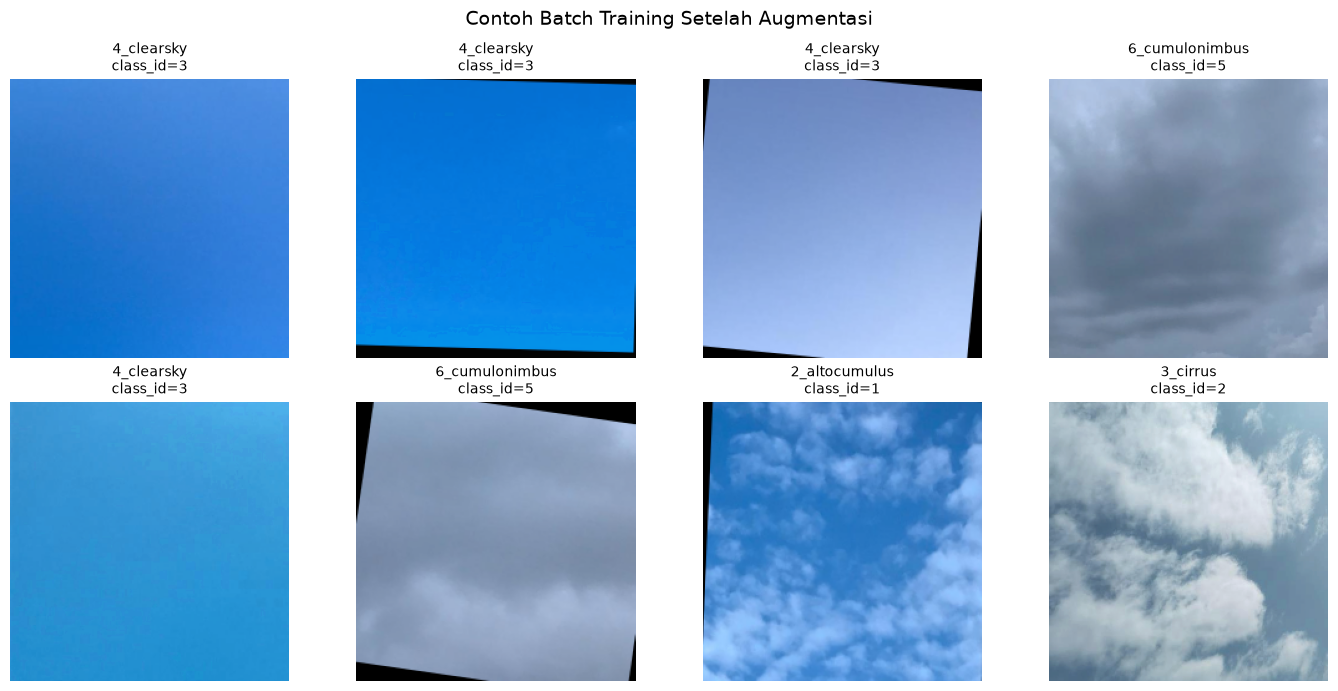

In [23]:
MAX_IMAGES_TO_SHOW = min(
    8,
    len(train_images),
)

figure, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)

axes = axes.flatten()


for index, axis in enumerate(axes):
    axis.axis("off")

    if index >= MAX_IMAGES_TO_SHOW:
        continue


    image = denormalize_image(
        image_tensor=train_images[index],
        mean=normalization_mean,
        std=normalization_std,
    )

    class_id = int(
        train_labels[index].item()
    )

    class_name = idx_to_class[
        class_id
    ]


    axis.imshow(image)

    axis.set_title(
        f"{class_name}\nclass_id={class_id}",
        fontsize=10,
    )


figure.suptitle(
    "Contoh Batch Training Setelah Augmentasi",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## Memeriksa Reproducibility Urutan Sampel

Dua RandomSampler dengan seed yang sama harus menghasilkan urutan indeks awal yang
sama. Pemeriksaan ini menguji pengacakan sampel, bukan hasil acak setiap augmentasi.

In [24]:
generator_one = torch.Generator()
generator_one.manual_seed(SEED)

generator_two = torch.Generator()
generator_two.manual_seed(SEED)


sampler_one = RandomSampler(
    train_dataset,
    generator=generator_one,
)

sampler_two = RandomSampler(
    train_dataset,
    generator=generator_two,
)


sample_order_one = list(
    iter(sampler_one)
)[:20]

sample_order_two = list(
    iter(sampler_two)
)[:20]


assert sample_order_one == sample_order_two, (
    "Urutan sampel tidak reproducible."
)


print("Urutan sampel reproducible.")
print(f"20 indeks awal: {sample_order_one}")

Urutan sampel reproducible.
20 indeks awal: [2964, 521, 1758, 6543, 6040, 7831, 3434, 5715, 6150, 627, 2180, 6321, 5962, 430, 5225, 6039, 7715, 183, 4569, 5210]


## Menyimpan Metadata DataLoader

Objek DataLoader tidak disimpan sebagai file karena dibentuk saat runtime.
Konfigurasi dan ringkasannya disimpan agar dapat digunakan kembali pada tahap
training dan dokumentasi eksperimen.

In [25]:
dataloader_summary_df.to_csv(
    DATALOADER_SUMMARY_PATH,
    index=False,
)

In [26]:
dataloader_config = {
    "project": (
        "Ground-based Cloud Dataset classification"
    ),
    "stage": "06_dataloader",

    "random_seed": SEED,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": PERSISTENT_WORKERS,
    "drop_last": DROP_LAST,

    "number_of_classes": NUM_CLASSES,
    "class_to_idx": class_to_idx,

    "split_configuration": {
        "train": {
            "samples": len(train_dataset),
            "batches": len(train_loader),
            "shuffle": True,
            "transform": "train_transform.json",
        },
        "val": {
            "samples": len(val_dataset),
            "batches": len(val_loader),
            "shuffle": False,
            "transform": "eval_transform.json",
        },
        "test": {
            "samples": len(test_dataset),
            "batches": len(test_loader),
            "shuffle": False,
            "transform": "eval_transform.json",
            "policy": "reserved_for_final_evaluation",
        },
    },

    "input_files": {
        "dataset_index": str(
            DATASET_INDEX_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "class_mapping": str(
            CLASS_MAPPING_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "preprocessing_config": str(
            PREPROCESSING_CONFIG_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "train_transform": str(
            TRAIN_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "eval_transform": str(
            EVAL_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "output_files": {
        "dataloader_summary": str(
            DATALOADER_SUMMARY_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "dataloader_config": str(
            DATALOADER_CONFIG_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },

    "software": {
        "python": sys.version.split()[0],
        "pytorch": torch.__version__,
        "albumentations": A.__version__,
        "opencv": cv2.__version__,
    },
}

In [27]:
with DATALOADER_CONFIG_PATH.open(
    "w",
    encoding="utf-8",
) as file_obj:
    json.dump(
        dataloader_config,
        file_obj,
        indent=2,
        ensure_ascii=False,
    )


print("Metadata DataLoader berhasil disimpan:")
print(
    "- "
    f"{DATALOADER_SUMMARY_PATH.relative_to(PROJECT_DIR)}"
)
print(
    "- "
    f"{DATALOADER_CONFIG_PATH.relative_to(PROJECT_DIR)}"
)

Metadata DataLoader berhasil disimpan:
- dataset\processed\dataloader_summary.csv
- dataset\processed\dataloader_config.json


## Pemeriksaan Akhir

Semua pemeriksaan harus memperoleh status `LULUS` sebelum DataLoader digunakan untuk
training model.

In [28]:
final_checks = {
    "Indeks preprocessing tersedia": (
        DATASET_INDEX_PATH.is_file()
    ),

    "Indeks preprocessing tidak kosong": (
        not samples_df.empty
    ),

    "Pemetaan kelas tersedia": (
        CLASS_MAPPING_PATH.is_file()
        and NUM_CLASSES > 1
    ),

    "Seluruh kelas berhasil dipetakan": (
        samples_df["class_id"].notna().all()
    ),

    "Seluruh file citra tersedia": (
        missing_images_df.empty
    ),

    "Dataset training tidak kosong": (
        len(train_dataset) > 0
    ),

    "Dataset validation tidak kosong": (
        len(val_dataset) > 0
    ),

    "Dataset test tidak kosong": (
        len(test_dataset) > 0
    ),

    "DataLoader training tersedia": (
        len(train_loader) > 0
    ),

    "DataLoader validation tersedia": (
        len(val_loader) > 0
    ),

    "DataLoader test tersedia": (
        len(test_loader) > 0
    ),

    "Batch training memiliki empat dimensi": (
        train_images.ndim == 4
    ),

    "Batch validation memiliki empat dimensi": (
        val_images.ndim == 4
    ),

    "Citra menggunakan tiga channel RGB": (
        train_images.shape[1] == 3
        and val_images.shape[1] == 3
    ),

    "Tensor training tidak mengandung NaN": (
        torch.isfinite(train_images).all().item()
    ),

    "Tensor validation tidak mengandung NaN": (
        torch.isfinite(val_images).all().item()
    ),

    "Label training berada dalam rentang kelas": (
        train_labels.min().item() >= 0
        and train_labels.max().item() < NUM_CLASSES
    ),

    "Label validation berada dalam rentang kelas": (
        val_labels.min().item() >= 0
        and val_labels.max().item() < NUM_CLASSES
    ),

    "Seluruh kelas tersedia pada setiap split": (
        not missing_class_split.any().any()
    ),

    "Urutan sampler reproducible": (
        sample_order_one == sample_order_two
    ),

    "Ringkasan DataLoader tersimpan": (
        DATALOADER_SUMMARY_PATH.is_file()
    ),

    "Konfigurasi DataLoader tersimpan": (
        DATALOADER_CONFIG_PATH.is_file()
    ),
}

In [29]:
final_check_df = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Status": [
        "LULUS" if passed else "GAGAL"
        for passed in final_checks.values()
    ],
})


display(final_check_df)

,Pemeriksaan,Status
0,Indeks preprocessing tersedia,LULUS
1,Indeks preprocessing tidak kosong,LULUS
2,Pemetaan kelas tersedia,LULUS
3,Seluruh kelas berhasil dipetakan,LULUS
4,Seluruh file citra tersedia,LULUS
5,Dataset training tidak kosong,LULUS
6,Dataset validation tidak kosong,LULUS
7,Dataset test tidak kosong,LULUS
8,DataLoader training tersedia,LULUS
9,DataLoader validation tersedia,LULUS


In [30]:
failed_checks = [
    check_name
    for check_name, passed
    in final_checks.items()
    if not passed
]


if failed_checks:
    raise RuntimeError(
        "Pemeriksaan akhir DataLoader gagal:\n"
        + "\n".join(
            f"- {check_name}"
            for check_name in failed_checks
        )
    )


print("=" * 72)
print("TAHAP 06 SELESAI")
print(
    "Dataset dan DataLoader train, validation, serta test "
    "berhasil disiapkan."
)
print(
    "Data test belum digunakan dan tetap disimpan "
    "untuk evaluasi akhir."
)
print("=" * 72)

TAHAP 06 SELESAI
Dataset dan DataLoader train, validation, serta test berhasil disiapkan.
Data test belum digunakan dan tetap disimpan untuk evaluasi akhir.


## Kesimpulan

Notebook `06_dataloader.ipynb` telah menghasilkan pipeline pemuatan data yang siap
digunakan dalam training model klasifikasi jenis awan.

Hasil tahap ini meliputi:

- indeks dataset dibaca dari metadata notebook 05 tanpa memindai ulang dataset;
- pemetaan kelas menggunakan `class_mapping.json`;
- pipeline augmentasi training dimuat dari `train_transform.json`;
- preprocessing validation dan test dimuat dari `eval_transform.json`;
- training DataLoader menggunakan pengacakan sampel;
- validation dan test DataLoader tidak menggunakan pengacakan;
- seluruh citra dikembalikan dalam format tensor `[batch, channel, height, width]`;
- label dikembalikan sebagai integer bertipe `torch.long`;
- seed Python, NumPy, PyTorch, worker, dan sampler telah dikendalikan;
- metadata konfigurasi DataLoader disimpan pada folder `dataset/processed`;
- data test belum digunakan untuk pemilihan model atau hyperparameter.

File tambahan yang dihasilkan:

```text
dataset/processed/
├── dataloader_summary.csv
└── dataloader_config.json